<a href="https://colab.research.google.com/github/JulianaOlivatti/Atividade_em_Grupo/blob/main/Atividade_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url_dados_spotify = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQLgqaky3kDKNl3UMvLYDQaEi4UUXVSf6foSqk5DUT_7iVP6M70OuRqk1YM9JBxW6rhnGWV0Du4J4BZ/pub?gid=638703295&single=true&output=csv"

df_spotify = pd.read_csv(url_dados_spotify)

display(df_spotify[["track_name", "track_artist"]].head(50))



,track_name,track_artist
0,Die With A Smile,"Lady Gaga, Bruno Mars"
1,BIRDS OF A FEATHER,Billie Eilish
2,That’s So True,Gracie Abrams
3,Taste,Sabrina Carpenter
4,APT.,"ROSÉ, Bruno Mars"
5,"Good Luck, Babe!",Chappell Roan
6,Diet Pepsi,Addison Rae
7,WILDFLOWER,Billie Eilish
8,Sailor Song,Gigi Perez
9,Timeless (with Playboi Carti),"The Weeknd, Playboi Carti"


In [ ]:
df_spotify["artistas_separados"] = df_spotify["track_artist"].str.split(",")
df_explodido = df_spotify.explode("artistas_separados")
df_explodido["artistas_separados"] = df_explodido["artistas_separados"].str.strip()

display(df_explodido[["track_name", "artistas_separados"]].head(20))

,track_name,artistas_separados
0,Die With A Smile,Lady Gaga
0,Die With A Smile,Bruno Mars
1,BIRDS OF A FEATHER,Billie Eilish
2,That’s So True,Gracie Abrams
3,Taste,Sabrina Carpenter
4,APT.,ROSÉ
4,APT.,Bruno Mars
5,"Good Luck, Babe!",Chappell Roan
6,Diet Pepsi,Addison Rae
7,WILDFLOWER,Billie Eilish


In [ ]:
max_popularidade = df_explodido["track_popularity"].max()
min_popularidade = df_explodido["track_popularity"].min()
amplitude_popularidade = max_popularidade - min_popularidade

print(f"Máxima popularidade: {max_popularidade}")
print(f"Mínima popularidade: {min_popularidade}")
print(f"Amplitude da popularidade: {amplitude_popularidade}")

indice_mais_popular = df_explodido["track_popularity"].idxmax()
musica_mais_popular = df_explodido.loc[indice_mais_popular, "track_name"]

print(f"Música mais popular: {musica_mais_popular}")

Máxima popularidade: 100
Mínima popularidade: 68
Amplitude da popularidade: 32
Música mais popular: 0    Die With A Smile
0    Die With A Smile
Name: track_name, dtype: object


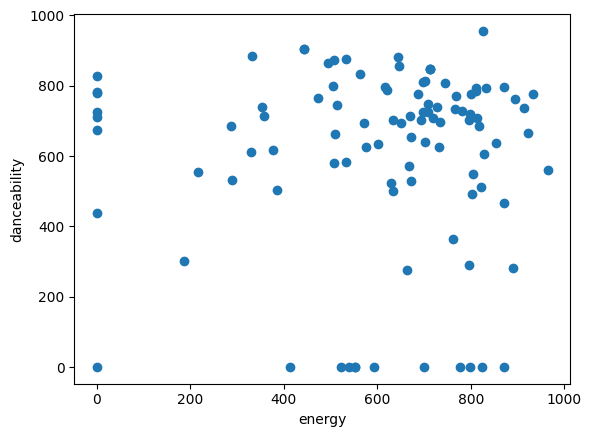

,energy,danceability,track_name
1419,827.00,956.00,Se Voce Nao Quer Passa a Vez
1192,533.00,584.00,Kiss from a Rose
762,444.00,906.00,No Heart
300,513.00,745.00,DOS DÍAS
895,922.00,666.00,Part Of Me
...,...,...,...
1402,709.00,725.00,Santa
1567,0.88,0.49,Chemical
1534,288.00,687.00,Male Fantasy
1398,769.00,771.00,El Efecto - Remix


In [ ]:
import matplotlib.pyplot as plt

amostra = df_explodido.sample(100, random_state=42)

plt.scatter(amostra["energy"], amostra["danceability"])
plt.xlabel("energy")
plt.ylabel("danceability")
plt.show()

display(amostra[["energy", "danceability", "track_name"]])